# U-Net Pipeline Applied

## Set Up

In [ ]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.5.1+cu118
True
Tesla V100-PCIE-32GB


In [ ]:
print(torch.cuda.current_device())
print(torch.cuda.get_device_name())

0
Tesla V100-PCIE-32GB


In [ ]:
import sys
print(sys.executable)

/hpc/jgeo610/Virtual_ENV/unet_env/bin/python


In [ ]:
import sys
sys.path.append('.')

import logging
import torch
from pathlib import Path

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:
import train
from unet import UNet

train.dir_img = Path('./data/imgs/')
train.dir_mask = Path('./data/masks/')
train.dir_checkpoint = Path('./checkpoints/')

<!-- ## Training U-Net Model -->

In [ ]:
model = UNet(n_channels=1, n_classes=6, bilinear=False)   # set n_classes to your actual count
model = model.to(memory_format=torch.channels_last)
model = model.to(device=device)

In [ ]:
# import numpy as np
# from pathlib import Path

# cache_dir = train.dir_img.parent / 'preprocessed_cache'
# patient_ids = [p.stem for p in sorted(train.dir_img.glob('*.dcm'))]

# corrupted = []
# for patient_id in patient_ids:
#     img_path = cache_dir / f'{patient_id}_img.npy'
#     mask_path = cache_dir / f'{patient_id}_mask.npy'
#     for p in [img_path, mask_path]:
#         if p.exists():
#             try:
#                 np.load(p, mmap_mode='r').shape
#             except Exception as e:
#                 print(f'CORRUPTED, deleting: {p} ({e})')
#                 p.unlink()
#                 corrupted.append(p)

# print(f'\nRemoved {len(corrupted)} corrupted file(s).')

In [ ]:
import numpy as np
from utils.data_loading import BasicDataset, VolumeMRIDataset

dataset = VolumeMRIDataset(train.dir_img, train.dir_mask, scale=1.0)

INFO: Found 49 patients, 4654 total slices
INFO: Scanning mask files to determine unique values...
INFO: Unique mask values: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]


In [ ]:
sample = dataset[0]
img = sample['image']
print('shape:', img.shape)
print('dtype:', img.dtype)
print('min:', img.min().item(), 'max:', img.max().item())

shape: torch.Size([1, 432, 432])
dtype: torch.float32
min: 0.0 max: 1.0


In [ ]:
for i in [0, 100, 500, 1000, 2000]:
    img = dataset[i]['image']
    print(i, img.min().item(), img.max().item(), torch.isnan(img).any().item(), torch.isinf(img).any().item())

0 0.0 1.0 False False
100 0.0 1.0 False False
500 0.0 1.0 False False
1000 0.0 1.0 False False
2000 0.0 1.0 False False


INFO: generated new fontManager


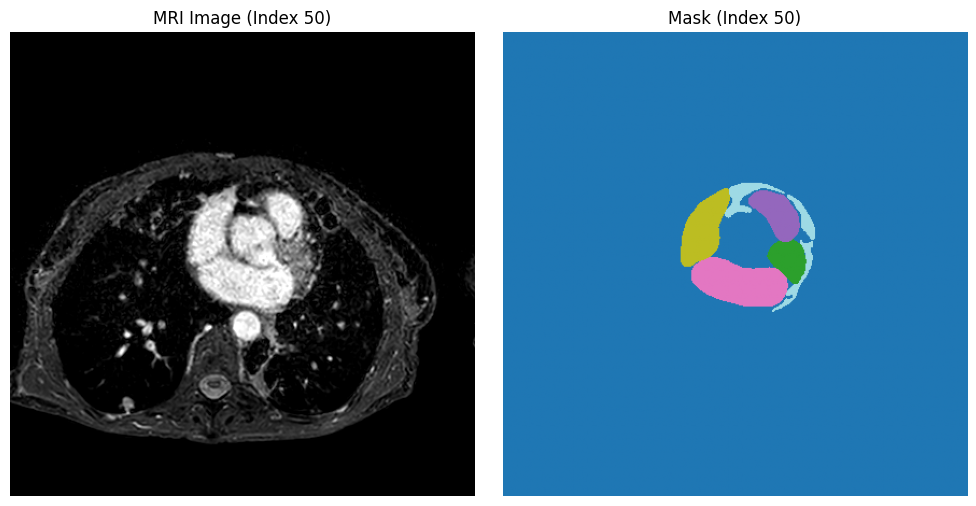

In [ ]:
import matplotlib.pyplot as plt

# 1. Fetch a specific slice index from your dataset instance
# (e.g., dataset[0] for the first slice, or dataset[50] for slice 50)
sample_idx = 50  
sample = dataset[sample_idx]

# 2. Extract image and mask tensors
# image shape is (1, H, W) -> squeeze to (H, W) for plotting
image_2d = sample['image'].squeeze(0).numpy()  
mask_2d = sample['mask'].numpy()               # shape: (H, W)

# 3. Plot image and mask side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot normalized MRI slice
axes[0].imshow(image_2d, cmap='gray')
axes[0].set_title(f'MRI Image (Index {sample_idx})')
axes[0].axis('off')

# Plot segmentation mask overlay
axes[1].imshow(mask_2d, cmap='tab20')  # 'tab20' gives clear distinct colors for integer classes
axes[1].set_title(f'Mask (Index {sample_idx})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
patient_id = sample['patient_id']
print(f"Loaded Patient: {patient_id}")

Loaded Patient: CADRE_1113


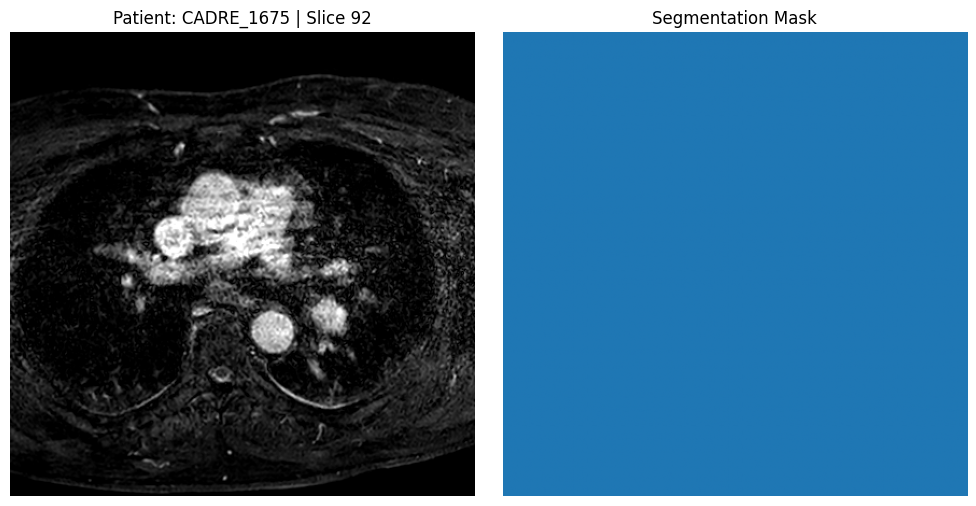

In [ ]:
import matplotlib.pyplot as plt

# 1. Target patient and slice
target_patient = "CADRE_1675"
target_slice = 92

# 2. Find the exact dataset index
try:
    sample_idx = next(
        idx for idx, (p_id, s_idx) in enumerate(dataset.index)
        if p_id == target_patient and s_idx == target_slice
    )
except StopIteration:
    raise ValueError(f"Slice {target_slice} for patient '{target_patient}' was not found in dataset.index.")

# 3. Load the sample
sample = dataset[sample_idx]
image_2d = sample['image'].squeeze(0).numpy()
mask_2d = sample['mask'].numpy()

# 4. Display the slice and mask side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image_2d, cmap='gray')
axes[0].set_title(f"Patient: {target_patient} | Slice {target_slice}")
axes[0].axis('off')

axes[1].imshow(mask_2d, cmap='tab20')
axes[1].set_title("Segmentation Mask")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# import numpy as np
# from utils.data_loading import BasicDataset, VolumeMRIDataset

# dataset = VolumeMRIDataset(train.dir_img, train.dir_mask, scale=1.0)

# for patient_id in dataset.mask_file_for:
#     img_path, mask_path = dataset._disk_cache_paths(patient_id)
#     for p in [img_path, mask_path]:
#         if p.exists():
#             try:
#                 np.load(p, mmap_mode='r').shape   # cheap check, doesn't load full array into memory
#             except Exception as e:
#                 print(f'CORRUPTED, deleting: {p} ({e})')
#                 p.unlink()

#     print('Done checking.')

In [ ]:
#from utils.data_loading import BasicDataset, VolumeMRIDataset

#dataset = VolumeMRIDataset(train.dir_img, train.dir_mask, scale=1.0)
# for patient_id in dataset.mask_file_for:
#     dataset._get_volume(patient_id)   # forces disk-cache creation for every patient, up front
# print('All patients cached to disk.')

In [ ]:
# import torch

# print("PyTorch:", torch.__version__)
# print("CUDA available:", torch.cuda.is_available())
# print("CUDA version:", torch.version.cuda)
# print("cuDNN version:", torch.backends.cudnn.version())
# print("cuDNN enabled:", torch.backends.cudnn.enabled)

# print(torch.cuda.get_device_name(0))

In [ ]:
# import torch

# print(torch.__version__)
# print(torch.backends.cudnn.version())

In [ ]:
# import torch
# import torch.nn as nn

# x = torch.randn(8, 1, 432, 432).cuda(0)

# conv = nn.Conv2d(1, 64, kernel_size=3, padding=1).cuda(0)

# y = conv(x)

# print(y.shape)

In [ ]:
# import torch

# print("PyTorch version:", torch.__version__)
# print("CUDA runtime:", torch.version.cuda)
# print("cuDNN:", torch.backends.cudnn.version())
# print("cuDNN enabled:", torch.backends.cudnn.enabled)

# print("GPU:", torch.cuda.get_device_name(0))
# print("Capability:", torch.cuda.get_device_capability(0))

In [ ]:
#train.train_model(model=model, device=device, epochs=1, batch_size=15, learning_rate=1e-5, val_percent=0.1, img_scale=1.0, amp=False)

In [ ]:
train.train_model(
    model=model,
    device=device,
    epochs=20,
    batch_size=8,
    learning_rate=1e-5,
    val_percent=0.1,
    img_scale=1.0,
    amp=True,
    run_name="batch_skip_20_epoch"
)

INFO: Found 49 patients, 4654 total slices
INFO: Scanning mask files to determine unique values...
INFO: Unique mask values: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /people/jgeo610/.netrc.
2026/07/20 21:42:42 ERROR main: failed to get logger path error="error opening log file: open /tmp/wandb/logs/core-debug-20260720_214242.log: permission denied"
2026/07/20 21:42:42 INFO server: will exit if parent process dies ppid=63695
2026/07/20 21:42:42 INFO server: accepting connections addr=/tmp/wandb-63695-14673-4081226597/socket
2026/07/20 21:42:42 INFO connection: ManageConnectionData: new connection created id=1(@)
wandb: Currently logged in as: jgeo610 (jgeo610-university-of-auckland) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
2026/07/20 21:42:43 INFO handleInformInit: received streamId=kexn4ljw id=1(@)
2026/07/20 21:42:43 INFO handleInformInit: stream started streamId=kexn4ljw id=1(@)


INFO: Starting training:
        Epochs:          20
        Batch size:      8
        Learning rate:   1e-05
        Training size:   4266
        Validation size: 388
        Checkpoints:     True
        Device:          cuda
        Images scaling:  1.0
        Mixed Precision: False
    
/hpc/jgeo610/heart_segmentation/train.py:127: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  grad_scaler = torch.cuda.amp.GradScaler(enabled=amp)
Epoch 1/20: 100%|██████████| 4266/4266 [2:16:44<00:00,  1.92s/img, loss (batch)=0.247]
INFO: Checkpoint 1 saved!
Epoch 2/20: 100%|██████████| 4266/4266 [17:17<00:00,  4.11img/s, loss (batch)=0.232]
INFO: Checkpoint 2 saved!
Epoch 3/20: 100%|██████████| 4266/4266 [13:09<00:00,  5.40img/s, loss (batch)=0.227]
INFO: Checkpoint 3 saved!
Epoch 4/20: 100%|██████████| 4266/4266 [13:18<00:00,  5.34img/s, loss (batch)=0.183]
INFO: Checkpoint 4 saved!
Epoch 5/20: 100%|██████████| 42

<!-- ## Evaluation Final Valdiation Score -->

In [8]:
# reconstructing dataset and validation split (what was used internally during training)

import random
from torch.utils.data import Subset, DataLoader

from utils.data_loading import VolumeMRIDataset

# must match what you passed to train_model
img_scale = 1.0 
val_percent = 0.1
batch_size = 15
dataset = VolumeMRIDataset(train.dir_img, train.dir_mask, scale=img_scale)

# mirrors the split logic inside train_model exactly
patients = list(dataset.mask_file_for.keys())
random.Random(0).shuffle(patients)
n_val_patients = max(1, int(len(patients) * val_percent))
val_patients = set(patients[:n_val_patients])

val_idx = [i for i, (p, _) in enumerate(dataset.index) if p in val_patients]
val_set = Subset(dataset, val_idx)
val_loader = DataLoader(val_set, shuffle=False, drop_last=True, batch_size=batch_size, num_workers=0, pin_memory=True)

print(f'{len(dataset.mask_file_for)} patients found: {list(dataset.mask_file_for.keys())}')
print(f'{len(dataset.mask_values)} mask values: {dataset.mask_values}')
print(f'{len(val_set)} validation slices')

INFO: Found 49 patients, 4654 total slices
INFO: Scanning mask files to determine unique values...
INFO: Unique mask values: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]


49 patients found: ['CADRE_1113', 'CADRE_1116_first', 'CADRE_1116_second', 'CADRE_1131', 'CADRE_1382_first', 'CADRE_1382_second', 'CADRE_1395', 'CADRE_1395_second', 'CADRE_1404_first', 'CADRE_1404_second', 'CADRE_1517', 'CADRE_1521', 'CADRE_1523', 'CADRE_1528', 'CADRE_1532', 'CADRE_1545', 'CADRE_1552', 'CADRE_1555', 'CADRE_1645', 'CADRE_1671', 'CADRE_1672', 'CADRE_1675', 'CADRE_1714', 'CADRE_1718', 'CADRE_1720', 'CADRE_1741', 'CADRE_1743', 'CADRE_1744', 'CADRE_1772', 'CADRE_1850', 'CADRE_1851', 'CADRE_1854', 'CADRE_1855', 'CADRE_1857', 'CADRE_1858', 'CADRE_1859', 'CADRE_1860', 'CADRE_1861', 'CADRE_1862', 'CADRE_1863', 'CADRE_1864', 'CADRE_1866', 'CADRE_1867', 'CADRE_1869', 'CADRE_1870', 'CADRE_1871', 'CADRE_1872', 'CADRE_1874', 'CADRE_1875']
6 mask values: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
388 validation slices


In [9]:
# saving trained model
dir_checkpoint = train.dir_checkpoint
dir_checkpoint.mkdir(parents=True, exist_ok=True)

state_dict = model.state_dict()
state_dict['mask_values'] = dataset.mask_values
torch.save(state_dict, dir_checkpoint / 'model_final.pth')
print('Saved to', dir_checkpoint / 'model_final.pth')

NameError: name 'model' is not defined

In [12]:
model = UNet(n_channels=1, n_classes=6, bilinear=False)
model = model.to(memory_format=torch.channels_last).to(device=device)

checkpoint_path = train.dir_checkpoint / 'checkpoint_epoch20.pth'   # adjust to whichever you want
state_dict = torch.load(checkpoint_path, map_location=device)
mask_values = state_dict.pop('mask_values')   # remove before loading, it's not a real weight
model.load_state_dict(state_dict)
model.eval()
print(f'Loaded {checkpoint_path.name}')

/tmp/ipykernel_26883/2536131103.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path, map_location=device)


Loaded checkpoint_epoch20.pth


In [ ]:
from evaluate import evaluate

val_score = evaluate(model, val_loader, device, amp=False)
print(f'Final validation Dice score: {val_score:.4f}')

## Visualize predictions on a few validation slices

In [10]:
import matplotlib
import IPython
#import matplotlib_inline

print("matplotlib:", matplotlib.__version__)
print("IPython:", IPython.__version__)
#print("matplotlib_inline:", matplotlib_inline.__version__)

matplotlib: 3.10.9
IPython: 8.39.0


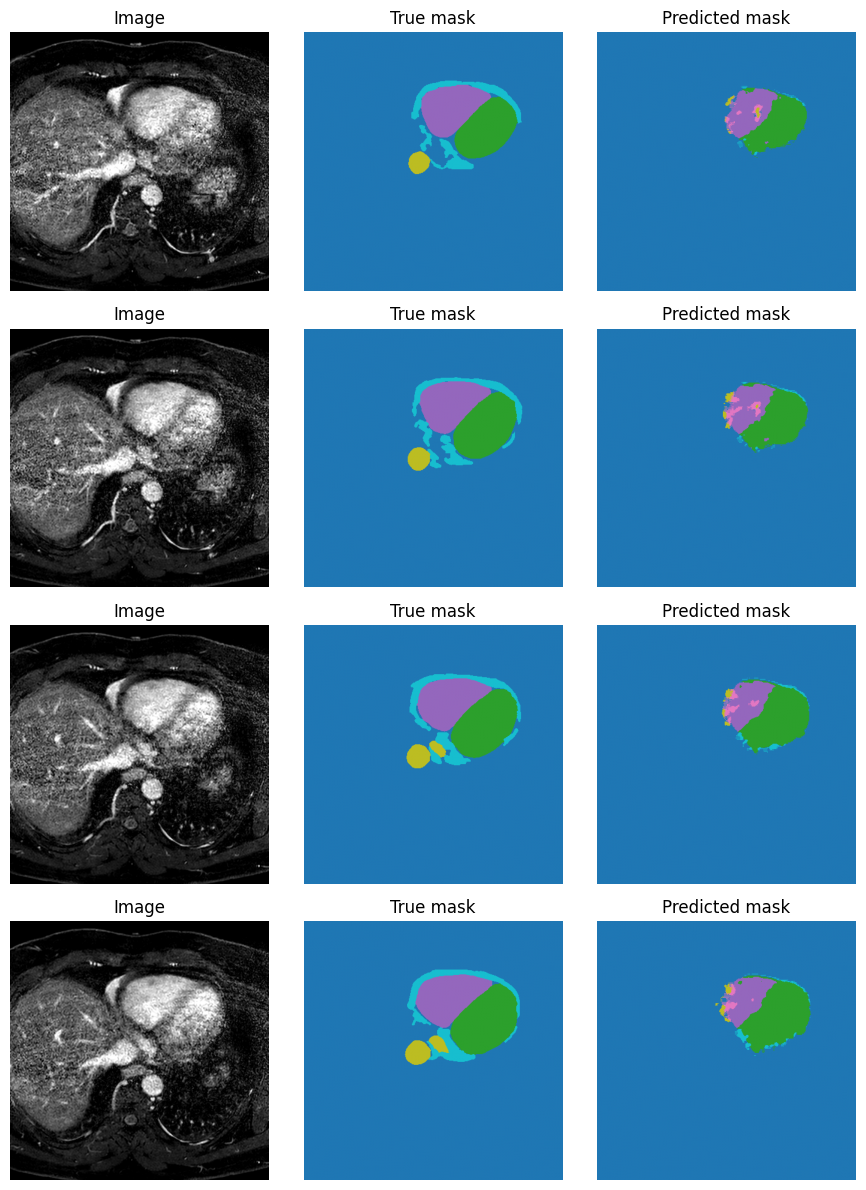

In [ ]:
# USE VISLOADER for visulaisation (set drop_last to False), but use val_loader for loss
import matplotlib.pyplot as plt

model.eval()
vis_loader = DataLoader(val_set, shuffle=False, drop_last=False, batch_size=batch_size, num_workers=0, pin_memory=True)
batch = next(iter(vis_loader))
images, true_masks = batch['image'], batch['mask']

with torch.no_grad():
    images_dev = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
    preds = model(images_dev).argmax(dim=1).cpu()

n_show = min(4, images.shape[0])
fig, ax = plt.subplots(n_show, 3, figsize=(9, 3 * n_show), squeeze=False)
for i in range(n_show):
    ax[i, 0].imshow(images[i, 0], cmap='gray');   ax[i, 0].set_title('Image')
    ax[i, 1].imshow(true_masks[i], cmap='tab10', vmin=0, vmax=model.n_classes - 1); ax[i, 1].set_title('True mask')
    ax[i, 2].imshow(preds[i], cmap='tab10', vmin=0, vmax=model.n_classes - 1); ax[i, 2].set_title('Predicted mask')
    for a in ax[i]: a.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
for i in range(n_show):
    original_idx = val_idx[i]
    patient_id, slice_idx = dataset.index[original_idx]
    print(f'Row {i}: patient = {patient_id}, slice = {slice_idx}')

Row 0: patient = CADRE_1872, slice = 0


In [ ]:
# import matplotlib.pyplot as plt

# model.eval()
# batch = next(iter(val_loader))
# images, true_masks = batch['image'], batch['mask']

# with torch.no_grad():
#     images_dev = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
#     preds = model(images_dev).argmax(dim=1).cpu()

# n_show = min(4, images.shape[0])
# fig, ax = plt.subplots(n_show, 3, figsize=(9, 3 * n_show))
# for i in range(n_show):
#     ax[i, 0].imshow(images[i, 0], cmap='gray');   ax[i, 0].set_title('Image')
#     ax[i, 1].imshow(true_masks[i], cmap='tab10'); ax[i, 1].set_title('True mask')
#     ax[i, 2].imshow(preds[i], cmap='tab10');      ax[i, 2].set_title('Predicted mask')
#     for a in ax[i]: a.axis('off')
# plt.tight_layout()
# plt.show()

### Per-class Dice breakdown

In [16]:
from utils.dice_score import dice_coeff

model.eval()
class_scores = torch.zeros(model.n_classes)
class_counts = torch.zeros(model.n_classes)

with torch.no_grad():
    for batch in val_loader:
        images = batch['image'].to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
        true_masks = batch['mask'].to(device=device, dtype=torch.long)
        preds = model(images).argmax(dim=1)

        for c in range(model.n_classes):
            pred_c = (preds == c).float()
            true_c = (true_masks == c).float()
            if true_c.sum() > 0:
                class_scores[c] += dice_coeff(pred_c, true_c, reduce_batch_first=True)
                class_counts[c] += 1

for c in range(model.n_classes):
    if class_counts[c] > 0:
        print(f'Class {c}: Dice = {class_scores[c] / class_counts[c]:.4f}')
    else:
        print(f'Class {c}: never present in validation set')

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [ ]:
print('patients:', patients)
print('val_patients:', val_patients)
print('len(dataset.index):', len(dataset.index))
print('len(val_idx):', len(val_idx))
print('len(train_idx):', len(train_idx) if 'train_idx' in dir() else 'not defined')

# manual count, bypassing the list comprehension entirely, as a cross-check
manual_count = 0
for p, s in dataset.index:
    if p in val_patients:
        manual_count += 1
print('manual count of matching entries:', manual_count)

patients: ['CADRE_1872', 'CADRE_1870', 'CADRE_1598', 'CADRE_1113', 'CADRE_1874', 'CADRE_1871', 'CADRE_1875']
val_patients: {'CADRE_1872'}
len(dataset.index): 7
len(val_idx): 1
len(train_idx): 6
manual count of matching entries: 1


In [ ]:
import pydicom
ds = pydicom.dcmread(train.dir_img / 'CADRE_1872.dcm')
print(ds.pixel_array.ndim, ds.pixel_array.shape)

4 (188, 432, 432, 3)


In [ ]:
dataset = VolumeMRIDataset(train.dir_img, train.dir_mask, scale=img_scale)

patients = list(dataset.mask_file_for.keys())
random.Random(0).shuffle(patients)
n_val_patients = max(1, int(len(patients) * val_percent))
val_patients = set(patients[:n_val_patients])

val_idx = [i for i, (p, _) in enumerate(dataset.index) if p in val_patients]
train_idx = [i for i, (p, _) in enumerate(dataset.index) if p not in val_patients]
val_set = Subset(dataset, val_idx)
train_set = Subset(dataset, train_idx)

print('val_patients:', val_patients)
print('val_set size:', len(val_set))

INFO: Found 7 patients, 7 total slices
INFO: Scanning mask files to determine unique values (loads every volume once)...
INFO: Unique mask values: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]


val_patients: {'CADRE_1872'}
val_set size: 1


In [ ]:
import pydicom

ds = pydicom.dcmread(train.dir_img / 'CADRE_1598.dcm')
print('pixel_array shape:', ds.pixel_array.shape)
print('SamplesPerPixel:', getattr(ds, 'SamplesPerPixel', 'not set'))
print('PhotometricInterpretation:', getattr(ds, 'PhotometricInterpretation', 'not set'))

pixel_array shape: (188, 432, 432, 3)
SamplesPerPixel: 3
PhotometricInterpretation: RGB


In [ ]:
import numpy as np
frame = ds.pixel_array[0]  # shape (432, 432, 3)
print(np.allclose(frame[..., 0], frame[..., 1]), np.allclose(frame[..., 1], frame[..., 2]))

True True
